In [43]:
import pandas as pd
df = pd.read_csv("level_coding_siswa_150.csv")
df

,hours_coding_daily,preferred_language,typing_speed,import_usage,oop_usage,level
0,4.0,Python,44,Yes,Yes,Advanced
1,5.0,C++,59,Yes,Yes,Advanced
2,5.0,Python,55,Yes,Yes,Advanced
3,5.0,Python,59,Yes,Yes,Advanced
4,5.0,Python,55,Yes,Yes,Advanced
...,...,...,...,...,...,...
169,2.5,C++,40,No,No,Intermediate
170,4.0,Python,48,Yes,Yes,Intermediate
171,5.0,C++,34,Yes,Yes,Intermediate
172,3.5,Java,45,Yes,No,Intermediate


In [44]:
df.shape

(174, 6)

In [45]:
df.columns

Index(['hours_coding_daily', 'preferred_language', 'typing_speed',
       'import_usage', 'oop_usage', 'level'],
      dtype='object')

In [46]:
df.describe()

,hours_coding_daily,typing_speed
count,174.000000,174.000000
mean,3.215517,38.810345
std,1.299551,14.306864
min,1.000000,20.000000
25%,2.000000,25.250000
50%,3.000000,38.000000
75%,4.000000,50.000000
max,5.500000,65.000000


In [47]:
df.head()

,hours_coding_daily,preferred_language,typing_speed,import_usage,oop_usage,level
0,4.0,Python,44,Yes,Yes,Advanced
1,5.0,C++,59,Yes,Yes,Advanced
2,5.0,Python,55,Yes,Yes,Advanced
3,5.0,Python,59,Yes,Yes,Advanced
4,5.0,Python,55,Yes,Yes,Advanced


In [48]:
df.tail()

,hours_coding_daily,preferred_language,typing_speed,import_usage,oop_usage,level
169,2.5,C++,40,No,No,Intermediate
170,4.0,Python,48,Yes,Yes,Intermediate
171,5.0,C++,34,Yes,Yes,Intermediate
172,3.5,Java,45,Yes,No,Intermediate
173,3.0,C++,38,Yes,No,Intermediate


In [49]:
df.dtypes

hours_coding_daily    float64
preferred_language     object
typing_speed            int64
import_usage           object
oop_usage              object
level                  object
dtype: object

In [50]:
df["hours_coding_daily"].value_counts

<bound method IndexOpsMixin.value_counts of 0      4.0
1      5.0
2      5.0
3      5.0
4      5.0
      ... 
169    2.5
170    4.0
171    5.0
172    3.5
173    3.0
Name: hours_coding_daily, Length: 174, dtype: float64>

In [51]:
df["preferred_language"].value_counts

<bound method IndexOpsMixin.value_counts of 0      Python
1         C++
2      Python
3      Python
4      Python
        ...  
169       C++
170    Python
171       C++
172      Java
173       C++
Name: preferred_language, Length: 174, dtype: object>

In [52]:
df["typing_speed"].value_counts

<bound method IndexOpsMixin.value_counts of 0      44
1      59
2      55
3      59
4      55
       ..
169    40
170    48
171    34
172    45
173    38
Name: typing_speed, Length: 174, dtype: int64>

In [53]:
df["import_usage"].value_counts

<bound method IndexOpsMixin.value_counts of 0      Yes
1      Yes
2      Yes
3      Yes
4      Yes
      ... 
169     No
170    Yes
171    Yes
172    Yes
173    Yes
Name: import_usage, Length: 174, dtype: object>

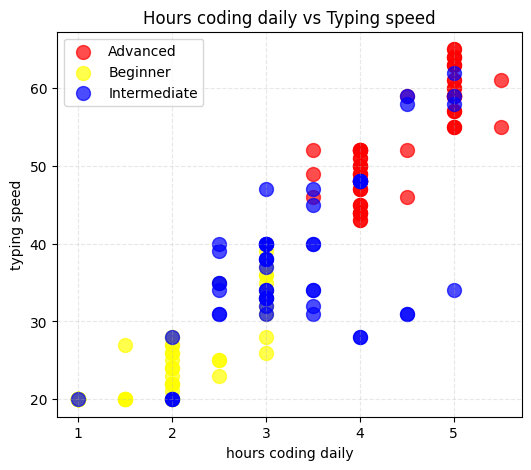

In [54]:
import matplotlib.pyplot as plt

advanced = df[df["level"]=="Advanced"]
beginner = df[df["level"]=="Beginner"]
intermediate = df[df["level"]=="Intermediate"]

plt.figure(figsize=(6,5))

plt.scatter(advanced["hours_coding_daily"], advanced["typing_speed"], s=100, alpha=0.7, color="red", label="Advanced")
plt.scatter(beginner["hours_coding_daily"], beginner["typing_speed"], s=100, alpha=0.7, color="yellow", label="Beginner")
plt.scatter(intermediate["hours_coding_daily"], intermediate["typing_speed"], s=100, alpha=0.7, color="blue", label="Intermediate")
plt.xlabel("hours coding daily")
plt.ylabel("typing speed")
plt.title("Hours coding daily vs Typing speed")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.show()

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["hours_coding_daily","preferred_language","typing_speed","import_usage","oop_usage"]]
y = df["level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["hours_coding_daily", "typing_speed"]
categorical_columns = ["import_usage","oop_usage"]
ordinal_columns = ["preferred_language"]

preferred_language_order = ["Python", "C++", "Java"]
ordinal_order = [preferred_language_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8857142857142857

Classification Report :
               precision    recall  f1-score   support

    Advanced       0.94      0.94      0.94        17
    Beginner       0.88      0.88      0.88         8
Intermediate       0.80      0.80      0.80        10

    accuracy                           0.89        35
   macro avg       0.87      0.87      0.87        35
weighted avg       0.89      0.89      0.89        35


Confusion Matrix :
 [[16  0  1]
 [ 0  7  1]
 [ 1  1  8]]


In [62]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("CV accuracy:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV accuracy: [0.78571429 0.82142857 0.82142857 0.89285714 0.85185185]
Mean CV accuracy: 0.8346560846560847


In [74]:
data_baru = pd.DataFrame([[5.5, "Python", 65, "Yes", "No"]],
                        columns=["hours_coding_daily","preferred_language","typing_speed","import_usage","oop_usage"])
prediksi = model.predict(data_baru)[0]
presentase = max(model.predict_proba(data_baru)[0])
print(f"Model Memprediksi {prediksi} dengan Tingkat Keyakinan {presentase*100:.2f}%")

Model Memprediksi Advanced dengan Tingkat Keyakinan 69.88%


In [ ]:
model.